# Scat Voice-To-Controls Laboratory

This notebook is a local SSH/dev-container lab for inspecting monophonic voice/scat recordings before fixing the final Bass-DDSP front-end architecture.

It visualizes candidate controls on the same 16 ms frame grid used by the Bass-DDSP model:

- `f0(t)`: TorchCREPE Hz estimate
- `loudness(t)`: frame RMS z-score
- `gate(t)`: causal Silero VAD state
- `offset(t)`: causal VAD falling-edge pulse
- `note_age(t)`: causal counter reset by onset
- `periodicity(t)`: TorchCREPE periodicity/confidence
- `onset_strength(t)`: research candidate tracks, not finalized
- `articulation_id(t)`: planned note-latched classifier output, not implemented here yet


In [12]:
# Colab / local setup
import importlib
import os
import subprocess
import sys
import warnings


def ensure(package, import_name=None):
    import_name = import_name or package
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])


ensure('librosa')
ensure('soundfile')
ensure('numpy')
ensure('matplotlib')
ensure('scipy')
ensure('pandas')
ensure('ipywidgets')
ensure('imageio-ffmpeg', 'imageio_ffmpeg')
# torchcrepe is used for f0/periodicity. It is optional at runtime because some envs need a torchaudio stub.

from pathlib import Path
import io
import math
import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from IPython.display import Audio, display

try:
    import torch
except ImportError as exc:
    raise ImportError('This notebook needs PyTorch for Silero VAD and optional ContentVec.') from exc

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.22
np.set_printoptions(precision=4, suppress=True)

workspace_candidates = [Path('/workspace'), Path.cwd(), Path.cwd().parent]
WORKSPACE_ROOT = next(
    (candidate for candidate in workspace_candidates if (candidate / 'learn').exists() or (candidate / 'contentvec').exists()),
    Path.cwd(),
)
CONTENTVEC_REPO = Path(os.environ.get('CONTENTVEC_REPO', WORKSPACE_ROOT / 'contentvec')).expanduser()
SILERO_VAD_REPO = Path(os.environ.get('SILERO_VAD_REPO', WORKSPACE_ROOT / 'silero-vad')).expanduser()
_checkpoint_env = os.environ.get('CONTENTVEC_CHECKPOINT', '').strip()
CONTENTVEC_CHECKPOINT = Path(_checkpoint_env).expanduser() if _checkpoint_env else None

print('workspace root:', WORKSPACE_ROOT)
print('contentvec repo:', CONTENTVEC_REPO)
print('silero-vad repo:', SILERO_VAD_REPO)
print('CONTENTVEC_CHECKPOINT:', CONTENTVEC_CHECKPOINT or '(not set)')


workspace root: /workspace
contentvec repo: /workspace/contentvec
silero-vad repo: /workspace/silero-vad
CONTENTVEC_CHECKPOINT: (not set)


## 1. Choose Or Upload A Voice Input

This notebook is intended for the local SSH/dev-container workflow, not Google Colab.

Recommended workflow:
1. Record a short scat/voice file on your local machine or phone.
2. Put it under `/workspace/learn/voice_inputs/` in the container, or set `AUDIO_PATH` to the exact file path.
3. Run the loader cell. If `AUDIO_PATH` is empty, it automatically chooses the newest supported audio file in `voice_inputs`.

Direct microphone recording from Python is not reliable through SSH/dev containers because the kernel runs inside the remote container, not on your laptop. The optional uploader widget below works in some VS Code/Jupyter frontends; if it does not appear, manually copy or drag the file into `voice_inputs`.


### Optional Local Upload Widget

Run this cell if your VS Code/Jupyter frontend supports `ipywidgets.FileUpload`. Choose a local audio file, press **Save uploaded audio**, then run the loader cell below. If the widget does not work in your frontend, skip it and manually put files in `/workspace/learn/voice_inputs/`.


In [13]:
INPUT_DIR = WORKSPACE_ROOT / 'learn' / 'voice_inputs'
INPUT_DIR.mkdir(parents=True, exist_ok=True)
SUPPORTED_AUDIO_EXTENSIONS = ('.wav', '.flac', '.mp3', '.ogg', '.m4a', '.aac')


def _iter_widget_uploads(value):
    if isinstance(value, dict):
        return list(value.values())
    if isinstance(value, (tuple, list)):
        return list(value)
    return []


try:
    import ipywidgets as widgets

    audio_uploader = widgets.FileUpload(
        accept=','.join(SUPPORTED_AUDIO_EXTENSIONS),
        multiple=False,
        description='Choose audio',
    )
    save_upload_button = widgets.Button(
        description='Save uploaded audio',
        button_style='primary',
    )
    upload_status = widgets.Output()

    def save_uploaded_audio(_=None):
        with upload_status:
            upload_status.clear_output()
            items = _iter_widget_uploads(audio_uploader.value)
            if not items:
                print('No file selected yet.')
                return
            item = items[0]
            name = item.get('name', 'uploaded_audio.wav')
            content = item.get('content', b'')
            if isinstance(content, memoryview):
                content = content.tobytes()
            out_path = INPUT_DIR / Path(name).name
            out_path.write_bytes(bytes(content))
            globals()['AUDIO_PATH'] = str(out_path)
            print('Saved:', out_path)
            print('AUDIO_PATH is now set for the loader cell.')

    save_upload_button.on_click(save_uploaded_audio)
    display(widgets.VBox([audio_uploader, save_upload_button, upload_status]))
except Exception as exc:
    print('ipywidgets upload UI is unavailable:', type(exc).__name__, exc)
    print('Manual path: copy audio files into', INPUT_DIR)


In [14]:
TARGET_SR = 16000

# Set this to an exact path when you want deterministic input selection.
# Example: AUDIO_PATH = '/workspace/learn/voice_inputs/ddang_take_01.wav'
AUDIO_PATH = globals().get('AUDIO_PATH', '')

INPUT_DIR = globals().get('INPUT_DIR', WORKSPACE_ROOT / 'learn' / 'voice_inputs')
INPUT_DIR = Path(INPUT_DIR)
INPUT_DIR.mkdir(parents=True, exist_ok=True)
SUPPORTED_AUDIO_EXTENSIONS = globals().get(
    'SUPPORTED_AUDIO_EXTENSIONS',
    ('.wav', '.flac', '.mp3', '.ogg', '.m4a', '.aac'),
)


def synthesize_fallback_scat(sr=TARGET_SR):
    rng = np.random.default_rng(7)
    syllables = []
    f0s = [105.0, 138.0, 92.0, 164.0]
    durations = [0.42, 0.36, 0.50, 0.44]
    for i, (f0, dur) in enumerate(zip(f0s, durations)):
        n = int(round(dur * sr))
        t = np.arange(n) / sr
        onset_noise = rng.normal(0, 1, n) * np.exp(-t / 0.018)
        vowel_env = (1.0 - np.exp(-t / 0.035)) * np.exp(-t / 0.65)
        vibrato = 0.012 * np.sin(2 * np.pi * 5.5 * t + i)
        phase = 2 * np.pi * np.cumsum(f0 * (1 + vibrato)) / sr
        harmonic = np.sin(phase) + 0.35 * np.sin(2 * phase + 0.4) + 0.16 * np.sin(3 * phase + 1.1)
        syllable = 0.65 * harmonic * vowel_env + 0.20 * onset_noise
        syllables.append(syllable.astype(np.float32))
        syllables.append(np.zeros(int(0.06 * sr), dtype=np.float32))
    y = np.concatenate(syllables)
    y = y / max(np.max(np.abs(y)), 1e-7) * 0.9
    return y.astype(np.float32), sr, 'synthetic_fallback_scat.wav'


def list_audio_inputs(input_dir=INPUT_DIR):
    files = []
    for ext in SUPPORTED_AUDIO_EXTENSIONS:
        files.extend(input_dir.rglob(f'*{ext}'))
        files.extend(input_dir.rglob(f'*{ext.upper()}'))
    return sorted(set(files), key=lambda p: p.stat().st_mtime, reverse=True)


def choose_audio_path():
    explicit = str(AUDIO_PATH).strip() if AUDIO_PATH is not None else ''
    if explicit:
        return Path(explicit).expanduser(), 'explicit AUDIO_PATH'
    candidates = list_audio_inputs(INPUT_DIR)
    if candidates:
        return candidates[0], 'newest file in voice_inputs'
    return None, 'fallback synthetic signal'


def decode_audio_with_ffmpeg(audio_path, target_sr=TARGET_SR):
    try:
        import imageio_ffmpeg
    except Exception as exc:
        raise RuntimeError(
            'imageio-ffmpeg is not available. Re-run the setup cell, or convert the file to WAV/FLAC first.'
        ) from exc

    ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()
    cmd = [
        ffmpeg_exe,
        '-v', 'error',
        '-i', str(audio_path),
        '-f', 'f32le',
        '-acodec', 'pcm_f32le',
        '-ac', '1',
        '-ar', str(target_sr),
        '-',
    ]
    proc = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    if proc.returncode != 0:
        stderr = proc.stderr.decode('utf-8', errors='replace').strip()
        raise RuntimeError(f'ffmpeg decode failed for {audio_path}: {stderr}')
    y = np.frombuffer(proc.stdout, dtype=np.float32).copy()
    if y.size == 0:
        raise RuntimeError(f'ffmpeg decoded zero samples from {audio_path}')
    return y.astype(np.float32), target_sr


def load_audio_file(audio_path, target_sr=TARGET_SR):
    audio_path = Path(audio_path).expanduser()
    if not audio_path.exists():
        raise FileNotFoundError(f'audio file does not exist: {audio_path}')
    if audio_path.stat().st_size == 0:
        raise ValueError(f'audio file is empty: {audio_path}')

    compressed_extensions = {'.m4a', '.aac', '.mp3', '.ogg'}
    prefer_ffmpeg = audio_path.suffix.lower() in compressed_extensions

    first_exc = None
    if not prefer_ffmpeg:
        try:
            y, sr = librosa.load(audio_path, sr=target_sr, mono=True)
            return y.astype(np.float32), sr, 'librosa/soundfile'
        except Exception as exc:
            first_exc = exc

    try:
        y, sr = decode_audio_with_ffmpeg(audio_path, target_sr)
        return y.astype(np.float32), sr, 'imageio-ffmpeg'
    except Exception as second_exc:
        if prefer_ffmpeg:
            try:
                y, sr = librosa.load(audio_path, sr=target_sr, mono=True)
                return y.astype(np.float32), sr, 'librosa/soundfile'
            except Exception as exc:
                first_exc = exc
        raise RuntimeError(
            'Could not decode audio file. '
            f'Path: {audio_path}\n'
            f'File size: {audio_path.stat().st_size} bytes\n'
            f'librosa/soundfile error: {type(first_exc).__name__}: {first_exc}\n'
            f'ffmpeg fallback error: {type(second_exc).__name__}: {second_exc}\n'
            'Fast workaround: convert the recording to WAV/FLAC, or re-run the setup cell so imageio-ffmpeg is installed.'
        ) from second_exc


def load_local_or_fallback():
    chosen_path, reason = choose_audio_path()
    if chosen_path is not None:
        y, sr, decoder = load_audio_file(chosen_path, TARGET_SR)
        return y.astype(np.float32), sr, str(chosen_path), f'{reason}; decoder={decoder}'
    return (*synthesize_fallback_scat(TARGET_SR), reason)


available_inputs = list_audio_inputs(INPUT_DIR)
print('input directory:', INPUT_DIR)
print('supported extensions:', SUPPORTED_AUDIO_EXTENSIONS)
print('available audio files:', len(available_inputs))
for candidate in available_inputs[:8]:
    print('  ', candidate)
if len(available_inputs) > 8:
    print('  ...')

y, sr, source_name, source_reason = load_local_or_fallback()
y, _ = librosa.effects.trim(y, top_db=45)
y = y.astype(np.float32)
y = y / max(np.max(np.abs(y)), 1e-7) * 0.95

print('source:', source_name)
print('selection:', source_reason)
print('sample rate:', sr)
print('duration:', len(y) / sr, 'seconds')
display(Audio(y, rate=sr))


input directory: /workspace/learn/voice_inputs
supported extensions: ('.wav', '.flac', '.mp3', '.ogg', '.m4a', '.aac')
available audio files: 1
   /workspace/learn/voice_inputs/Scat 1.m4a
source: /workspace/learn/voice_inputs/Scat 1.m4a
selection: explicit AUDIO_PATH; decoder=imageio-ffmpeg
sample rate: 16000
duration: 7.968 seconds


## 2. Extract 16 ms Frame Features

The master control interval is `16 ms` (`256` samples at `16 kHz`). The analysis window is `32 ms`, which also aligns with Silero VAD's `512`-sample causal chunks.

MFCC is still visualized for inspection, but the current articulation plan does not rely on MFCC as the main classifier feature because it can carry speaker identity. The articulation candidates below focus more on spectral tilt, high-frequency ratio, periodicity, and ContentVec-style content boundaries.


In [15]:
HOP_SECONDS = 0.016
FRAME_SECONDS = 0.032
N_MFCC = 20
HIGH_FREQ_CUTOFF_HZ = 3000.0
LOW_MID_MAX_HZ = 3000.0
LOW_MID_MIN_HZ = 250.0

hop_length = int(round(HOP_SECONDS * sr))
win_length = int(round(FRAME_SECONDS * sr))
n_fft = 1
while n_fft < win_length:
    n_fft *= 2

stft = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, win_length=win_length, center=True)
mag = np.abs(stft).astype(np.float32)
power = mag ** 2
freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
times = librosa.frames_to_time(np.arange(mag.shape[1]), sr=sr, hop_length=hop_length)
frame_end_times = times + HOP_SECONDS / 2.0


def align_length(x, target_len, fill=0.0):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if len(x) == target_len:
        return x
    if len(x) == 0:
        return np.full(target_len, fill, dtype=np.float32)
    if len(x) > target_len:
        return x[:target_len].astype(np.float32)
    return np.pad(x, (0, target_len - len(x)), constant_values=fill).astype(np.float32)


def robust_normalize(x):
    x = np.asarray(x, dtype=np.float32)
    lo, hi = np.percentile(x, [5, 95]) if x.size else (0.0, 1.0)
    return np.clip((x - lo) / max(float(hi - lo), 1e-7), 0.0, 1.0).astype(np.float32)


def masked_zscore(x, mask=None):
    x = np.asarray(x, dtype=np.float32)
    if mask is not None and np.any(mask):
        ref = x[np.asarray(mask).astype(bool)]
    else:
        ref = x
    mu = float(np.mean(ref)) if ref.size else 0.0
    sigma = float(np.std(ref)) if ref.size else 1.0
    return ((x - mu) / max(sigma, 1e-6)).astype(np.float32)


mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, n_fft=n_fft, hop_length=hop_length, win_length=win_length)
mfcc_delta = librosa.feature.delta(mfcc)
zcr = align_length(
    librosa.feature.zero_crossing_rate(y, frame_length=win_length, hop_length=hop_length, center=True)[0],
    len(times),
)

# Spectral flux: positive frame-to-frame spectral change after L1 magnitude normalization.
mag_norm = mag / np.maximum(np.sum(mag, axis=0, keepdims=True), 1e-8)
diff = np.diff(mag_norm, axis=1)
positive_diff = np.maximum(diff, 0.0)
negative_diff = np.maximum(-diff, 0.0)
spectral_flux = np.concatenate([[0.0], np.sqrt(np.sum(positive_diff ** 2, axis=0))]).astype(np.float32)
spectral_drop = np.concatenate([[0.0], np.sqrt(np.sum(negative_diff ** 2, axis=0))]).astype(np.float32)
flux_norm = robust_normalize(spectral_flux)
drop_norm = robust_normalize(spectral_drop)
zcr_norm = robust_normalize(zcr)

frame_rms = align_length(
    librosa.feature.rms(S=mag, frame_length=n_fft, hop_length=hop_length, center=True)[0],
    len(times),
)
rms_db = (20.0 * np.log10(np.maximum(frame_rms, 1e-7))).astype(np.float32)
energy_norm = robust_normalize(rms_db)

try:
    _, percussive_stft = librosa.decompose.hpss(stft, margin=8.0)
    hpss_percussive = np.mean(np.abs(percussive_stft), axis=0).astype(np.float32)
except Exception as exc:
    print('HPSS failed:', type(exc).__name__, exc)
    hpss_percussive = np.zeros(len(times), dtype=np.float32)
hpss_percussive = align_length(hpss_percussive, len(times))
hpss_onset_norm = robust_normalize(hpss_percussive)

high_mask = freqs >= HIGH_FREQ_CUTOFF_HZ
low_mid_mask = (freqs >= LOW_MID_MIN_HZ) & (freqs < LOW_MID_MAX_HZ)
total_energy = np.maximum(np.sum(power, axis=0), 1e-10)
high_energy = np.sum(power[high_mask], axis=0) if np.any(high_mask) else np.zeros_like(total_energy)
low_mid_energy = np.sum(power[low_mid_mask], axis=0) if np.any(low_mid_mask) else np.zeros_like(total_energy)
high_freq_ratio = np.clip(high_energy / total_energy, 0.0, 1.0).astype(np.float32)
spectral_tilt = (10.0 * np.log10((high_energy + 1e-10) / (low_mid_energy + 1e-10))).astype(np.float32)
high_freq_ratio_norm = robust_normalize(high_freq_ratio)
spectral_tilt_norm = robust_normalize(spectral_tilt)

feature_tensor = np.concatenate([
    mfcc.T,
    mfcc_delta.T,
    zcr[:, None],
    spectral_flux[:, None],
    spectral_drop[:, None],
    rms_db[:, None],
    high_freq_ratio[:, None],
    spectral_tilt[:, None],
    hpss_percussive[:, None],
], axis=1).astype(np.float32)

feature_names = (
    [f'mfcc_{i:02d}' for i in range(N_MFCC)]
    + [f'delta_mfcc_{i:02d}' for i in range(N_MFCC)]
    + [
        'zcr',
        'spectral_flux',
        'spectral_drop',
        'rms_db',
        'high_freq_ratio',
        'spectral_tilt_db',
        'hpss_percussive',
    ]
)

print('control frame interval:', HOP_SECONDS, 'seconds')
print('hop_length:', hop_length, 'samples')
print('win_length:', win_length, 'samples')
print('n_fft:', n_fft)
print('frames:', len(times))
print('mfcc:', mfcc.shape, '(coefficients, frames)')
print('spectral_flux:', spectral_flux.shape)
print('feature_tensor:', feature_tensor.shape, '(T, C)')


control frame interval: 0.016 seconds
hop_length: 256 samples
win_length: 512 samples
n_fft: 512
frames: 499
mfcc: (20, 499) (coefficients, frames)
spectral_flux: (499,)
feature_tensor: (499, 47) (T, C)


## 3. Candidate Consonant / Boundary Features

The orange markers are spectral-flux peaks only. They are not ground-truth onsets, and they can fire at offsets. This section keeps the candidate tracks separate so we can inspect which cue is actually useful on real scat recordings.


In [16]:
min_distance_frames = max(1, int(round(0.080 / HOP_SECONDS)))

flux_peak_frames, flux_peak_properties = find_peaks(
    flux_norm,
    height=0.35,
    prominence=0.10,
    distance=min_distance_frames,
)
hpss_peak_frames, hpss_peak_properties = find_peaks(
    hpss_onset_norm,
    height=0.35,
    prominence=0.10,
    distance=min_distance_frames,
)

flux_peak_times = times[flux_peak_frames]
hpss_peak_times = times[hpss_peak_frames]

print('spectral-flux candidate frames:', flux_peak_frames.tolist())
print('spectral-flux candidate times:', np.round(flux_peak_times, 3).tolist())
print('HPSS candidate frames:', hpss_peak_frames.tolist())
print('HPSS candidate times:', np.round(hpss_peak_times, 3).tolist())


spectral-flux candidate frames: [1, 17, 31, 50, 59, 64, 71, 81, 141, 147, 157, 165, 173, 183, 193, 208, 213, 221, 232, 237, 269, 274, 291, 297, 303, 318, 330, 343, 352, 366, 373, 385, 395, 404, 411, 442, 447, 452, 458, 467, 489, 497]
spectral-flux candidate times: [0.016, 0.272, 0.496, 0.8, 0.944, 1.024, 1.136, 1.296, 2.256, 2.352, 2.512, 2.64, 2.768, 2.928, 3.088, 3.328, 3.408, 3.536, 3.712, 3.792, 4.304, 4.384, 4.656, 4.752, 4.848, 5.088, 5.28, 5.488, 5.632, 5.856, 5.968, 6.16, 6.32, 6.464, 6.576, 7.072, 7.152, 7.232, 7.328, 7.472, 7.824, 7.952]
HPSS candidate frames: [4, 13, 34, 48, 59, 70, 80, 174, 184, 192, 207, 217, 223, 231, 245, 251, 305, 311, 324, 329, 334, 340, 346, 351, 369, 393, 443, 457, 478]
HPSS candidate times: [0.064, 0.208, 0.544, 0.768, 0.944, 1.12, 1.28, 2.784, 2.944, 3.072, 3.312, 3.472, 3.568, 3.696, 3.92, 4.016, 4.88, 4.976, 5.184, 5.264, 5.344, 5.44, 5.536, 5.616, 5.904, 6.288, 7.088, 7.312, 7.648]


## 4. Causal VAD, TorchCREPE, ContentVec, And Proposed Control Tracks

This section produces the current laboratory control proposal:

- `gate(t)`: causal Silero VAD with hysteresis
- `offset(t)`: falling edge of the causal gate
- `note_age(t)`: causal counter reset by the current onset pulse
- `f0(t)`: TorchCREPE pitch in Hz
- `periodicity(t)`: TorchCREPE confidence/periodicity
- `loudness(t)`: RMS dB z-score over active frames
- `onset_strength(t)`: provisional candidate, shown for inspection only

ContentVec remains optional because this clone does not include a pretrained checkpoint.


In [17]:
VAD_OPEN_THRESHOLD = 0.50
VAD_CLOSE_THRESHOLD = 0.35
SILERO_CHUNK_SAMPLES = 512  # 32 ms at 16 kHz; Silero's causal streaming chunk size.
TORCHCREPE_MODEL = os.environ.get('TORCHCREPE_MODEL', 'tiny')
TORCHCREPE_DEVICE = os.environ.get('TORCHCREPE_DEVICE', 'cpu')
TORCHCREPE_FMIN = float(os.environ.get('TORCHCREPE_FMIN', '50.0'))
TORCHCREPE_FMAX = float(os.environ.get('TORCHCREPE_FMAX', '1000.0'))
CONTENTVEC_FRAME_SECONDS = 0.020  # HuBERT/ContentVec convolutional stride: 320 samples at 16 kHz.
CONTENTVEC_LAYER = int(os.environ.get('CONTENTVEC_LAYER', '12'))
CONTENTVEC_SPK_EMB_DIM = int(os.environ.get('CONTENTVEC_SPK_EMB_DIM', '256'))


def _interp_to_frame_times(values, value_times, target_times, fill=0.0):
    values = np.asarray(values, dtype=np.float32)
    value_times = np.asarray(value_times, dtype=np.float32)
    target_times = np.asarray(target_times, dtype=np.float32)
    if values.size == 0 or value_times.size == 0 or target_times.size == 0:
        return np.full(target_times.shape, fill, dtype=np.float32)
    return np.interp(
        target_times,
        value_times,
        values,
        left=float(values[0]),
        right=float(values[-1]),
    ).astype(np.float32)


def _sample_hold_to_frame_times(values, available_times, target_times, fill=0.0):
    values = np.asarray(values, dtype=np.float32)
    available_times = np.asarray(available_times, dtype=np.float32)
    target_times = np.asarray(target_times, dtype=np.float32)
    if values.size == 0 or available_times.size == 0 or target_times.size == 0:
        return np.full(target_times.shape, fill, dtype=np.float32)
    idx = np.searchsorted(available_times, target_times, side='right') - 1
    out = np.full(target_times.shape, fill, dtype=np.float32)
    valid = idx >= 0
    out[valid] = values[np.clip(idx[valid], 0, len(values) - 1)]
    if np.any(~valid):
        out[~valid] = values[0]
    return out.astype(np.float32)


def _pca_numpy(x, n_components=2):
    x = np.asarray(x, dtype=np.float32)
    if x.ndim != 2 or x.shape[0] < 2 or x.shape[1] < 1:
        return np.zeros((x.shape[0] if x.ndim == 2 else 0, n_components), dtype=np.float32)
    centered = x - np.mean(x, axis=0, keepdims=True)
    _, _, vt = np.linalg.svd(centered, full_matrices=False)
    n = min(n_components, vt.shape[0])
    projected = centered @ vt[:n].T
    if n < n_components:
        projected = np.pad(projected, ((0, 0), (0, n_components - n)))
    return projected.astype(np.float32)


def causal_hysteresis(prob, open_threshold=VAD_OPEN_THRESHOLD, close_threshold=VAD_CLOSE_THRESHOLD):
    prob = np.asarray(prob, dtype=np.float32).reshape(-1)
    gate = np.zeros_like(prob, dtype=np.float32)
    active = False
    for i, value in enumerate(prob):
        if active:
            if value <= close_threshold:
                active = False
        else:
            if value >= open_threshold:
                active = True
        gate[i] = 1.0 if active else 0.0
    return gate


def pulses_from_gate(gate):
    gate = np.asarray(gate, dtype=np.float32).reshape(-1)
    prev = np.concatenate([[0.0], gate[:-1]])
    onset = ((gate > 0.5) & (prev <= 0.5)).astype(np.float32)
    offset = ((gate <= 0.5) & (prev > 0.5)).astype(np.float32)
    return onset, offset


def causal_note_age(gate, onset, frame_seconds=HOP_SECONDS):
    gate = np.asarray(gate, dtype=np.float32).reshape(-1)
    onset = np.asarray(onset, dtype=np.float32).reshape(-1)
    age = np.zeros_like(gate, dtype=np.float32)
    current_age = 0.0
    for i in range(len(gate)):
        if onset[i] > 0.5:
            current_age = 0.0
        if gate[i] > 0.5:
            age[i] = current_age
            current_age += frame_seconds
        else:
            current_age = 0.0
            age[i] = 0.0
    return age


def run_causal_silero_vad(audio, sr):
    if sr != 16000:
        raise ValueError('Silero VAD cell expects TARGET_SR == 16000.')
    jit_path = SILERO_VAD_REPO / 'src' / 'silero_vad' / 'data' / 'silero_vad.jit'
    if not jit_path.exists():
        return np.zeros(0, dtype=np.float32), np.zeros(0, dtype=np.float32), f'missing Silero JIT file: {jit_path}'

    model = torch.jit.load(str(jit_path), map_location='cpu')
    model.eval()
    if hasattr(model, 'reset_states'):
        model.reset_states()

    wav = torch.from_numpy(np.asarray(audio, dtype=np.float32))
    pad = (-len(wav)) % SILERO_CHUNK_SAMPLES
    if pad:
        wav = torch.nn.functional.pad(wav, (0, pad))

    probs = []
    available_times = []
    with torch.no_grad():
        for start in range(0, wav.numel(), SILERO_CHUNK_SAMPLES):
            chunk = wav[start:start + SILERO_CHUNK_SAMPLES]
            prob = float(model(chunk, sr).reshape(-1)[0].item())
            probs.append(prob)
            available_times.append((start + SILERO_CHUNK_SAMPLES) / sr)

    return (
        np.asarray(probs, dtype=np.float32),
        np.asarray(available_times, dtype=np.float32),
        f'loaded {jit_path}',
    )


def import_torchcrepe_safe():
    try:
        import importlib.machinery
        import types

        def install_torchaudio_stub():
            torchaudio = types.ModuleType('torchaudio')
            torchaudio.__spec__ = importlib.machinery.ModuleSpec('torchaudio', loader=None)
            def missing_load(*args, **kwargs):
                raise RuntimeError('torchaudio file loading is unavailable in this container; audio is decoded by librosa/ffmpeg.')
            torchaudio.load = missing_load
            sys.modules['torchaudio'] = torchaudio

        # In this dev container, the installed torchaudio package is present but linked
        # against unavailable CUDA libraries. TorchCREPE only needs torchaudio for its
        # file-loading helpers, so force a tiny stub before importing torchcrepe.
        for module_name in list(sys.modules):
            if module_name == 'torchaudio' or module_name.startswith('torchaudio.'):
                del sys.modules[module_name]
        install_torchaudio_stub()

        try:
            import torchcrepe
            return torchcrepe, 'imported torchcrepe with torchaudio stub'
        except Exception:
            for module_name in list(sys.modules):
                if module_name == 'torchcrepe' or module_name.startswith('torchcrepe.'):
                    del sys.modules[module_name]
            install_torchaudio_stub()
            import torchcrepe
            return torchcrepe, 'imported torchcrepe with torchaudio stub after retry'
    except Exception as exc:
        return None, f'torchcrepe unavailable: {type(exc).__name__}: {exc}'


def extract_torchcrepe_controls(audio, sr, hop_length):
    torchcrepe, import_status = import_torchcrepe_safe()
    if torchcrepe is None:
        return (
            np.zeros(len(times), dtype=np.float32),
            np.zeros(len(times), dtype=np.float32),
            import_status,
        )
    try:
        device = TORCHCREPE_DEVICE
        if device == 'cuda' and not torch.cuda.is_available():
            device = 'cpu'
        wav = torch.from_numpy(np.asarray(audio, dtype=np.float32)).float().unsqueeze(0).to(device)
        with torch.no_grad():
            f0, periodicity = torchcrepe.predict(
                wav,
                sr,
                hop_length=hop_length,
                fmin=TORCHCREPE_FMIN,
                fmax=TORCHCREPE_FMAX,
                model=TORCHCREPE_MODEL,
                decoder=torchcrepe.decode.weighted_argmax,
                return_periodicity=True,
                batch_size=512,
                device=device,
                pad=True,
            )
        f0 = f0.squeeze(0).detach().cpu().numpy().astype(np.float32)
        periodicity = periodicity.squeeze(0).detach().cpu().numpy().astype(np.float32)
        f0 = align_length(f0, len(times), fill=0.0)
        periodicity = np.clip(align_length(periodicity, len(times), fill=0.0), 0.0, 1.0)
        return f0, periodicity, f'{import_status}; model={TORCHCREPE_MODEL}; device={device}'
    except Exception as exc:
        return (
            np.zeros(len(times), dtype=np.float32),
            np.zeros(len(times), dtype=np.float32),
            f'torchcrepe extraction failed: {type(exc).__name__}: {exc}',
        )


causal_vad_probs, causal_vad_times, causal_vad_status = run_causal_silero_vad(y, sr)
vad_prob_interp_16ms = _interp_to_frame_times(causal_vad_probs, causal_vad_times, times, fill=0.0)
vad_prob_16ms = _sample_hold_to_frame_times(causal_vad_probs, causal_vad_times, frame_end_times, fill=0.0)
gate = causal_hysteresis(vad_prob_16ms, VAD_OPEN_THRESHOLD, VAD_CLOSE_THRESHOLD)
onset = None
offset = None
onset, offset = pulses_from_gate(gate)
note_age = causal_note_age(gate, onset, HOP_SECONDS)

loudness_z = masked_zscore(rms_db, gate > 0.5)
f0_hz, periodicity, torchcrepe_status = extract_torchcrepe_controls(y, sr, hop_length)

print('causal VAD:', causal_vad_status)
print('causal VAD chunks:', len(causal_vad_probs), 'chunk_seconds:', SILERO_CHUNK_SAMPLES / sr)
print('causal VAD probability range:', (float(np.min(causal_vad_probs)), float(np.max(causal_vad_probs))) if causal_vad_probs.size else '(empty)')
print('gate active frames:', int(np.sum(gate)), '/', len(gate))
print('onset frames:', np.where(onset > 0.5)[0].tolist())
print('offset frames:', np.where(offset > 0.5)[0].tolist())
print('TorchCREPE:', torchcrepe_status)
print('f0 range on periodic frames:', (
    float(np.min(f0_hz[periodicity > 0.2])) if np.any(periodicity > 0.2) else 0.0,
    float(np.max(f0_hz[periodicity > 0.2])) if np.any(periodicity > 0.2) else 0.0,
))


def _find_contentvec_checkpoint():
    candidates = []
    if CONTENTVEC_CHECKPOINT is not None:
        candidates.append(CONTENTVEC_CHECKPOINT)
    candidates.extend([
        WORKSPACE_ROOT / 'checkpoints' / 'contentvec' / 'checkpoint_best_legacy.pt',
        WORKSPACE_ROOT / 'checkpoints' / 'contentvec' / 'checkpoint_best.pt',
        CONTENTVEC_REPO / 'checkpoints' / 'checkpoint_best_legacy.pt',
        CONTENTVEC_REPO / 'checkpoints' / 'checkpoint_best.pt',
    ])
    for candidate in candidates:
        if candidate is not None and candidate.exists():
            return candidate
    return None


def _extract_contentvec_features(audio, sr):
    ckpt = _find_contentvec_checkpoint()
    if ckpt is None:
        return None, None, 'skipped: no ContentVec checkpoint found. Set CONTENTVEC_CHECKPOINT to checkpoint_best_legacy.pt or checkpoint_best.pt.'
    if not CONTENTVEC_REPO.exists():
        return None, None, f'skipped: missing ContentVec repo at {CONTENTVEC_REPO}'

    if str(CONTENTVEC_REPO) not in sys.path:
        sys.path.insert(0, str(CONTENTVEC_REPO))

    try:
        import fairseq
    except Exception as exc:
        return None, None, f'skipped: fairseq is not importable ({type(exc).__name__}: {exc})'

    try:
        # Registers ContentVec model/task classes for fairseq checkpoint loading.
        import contentvec.models.hubert.contentvec  # noqa: F401
        import contentvec.tasks.contentvec_pretraining  # noqa: F401
    except Exception as exc:
        warnings.warn(f'ContentVec class registration warning: {type(exc).__name__}: {exc}')

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    try:
        models, cfg, task = fairseq.checkpoint_utils.load_model_ensemble_and_task([str(ckpt)])
        model = models[0].to(device).eval()
        wav = torch.from_numpy(np.asarray(audio, dtype=np.float32)).unsqueeze(0).to(device)
        padding_mask = torch.zeros(wav.shape, dtype=torch.bool, device=device)

        with torch.no_grad():
            try:
                out = model.extract_features(
                    source=wav,
                    padding_mask=padding_mask,
                    mask=False,
                    output_layer=CONTENTVEC_LAYER,
                )
            except TypeError:
                spk_emb = torch.zeros(1, CONTENTVEC_SPK_EMB_DIM, device=device)
                try:
                    out = model.extract_features(
                        wav,
                        spk_emb,
                        padding_mask=padding_mask,
                        mask=False,
                        output_layer=CONTENTVEC_LAYER,
                    )
                except TypeError:
                    out = model.extract_features(
                        source=wav,
                        spk_emb=spk_emb,
                        padding_mask=padding_mask,
                        mask=False,
                        output_layer=CONTENTVEC_LAYER,
                    )

        if isinstance(out, (tuple, list)):
            feats = out[0]
        elif isinstance(out, dict):
            feats = out.get('x', out.get('features'))
        else:
            feats = out
        if feats is None:
            return None, None, 'skipped: ContentVec returned no feature tensor.'
        feats = feats.squeeze(0).detach().cpu().numpy().astype(np.float32)
        cv_times = np.arange(feats.shape[0], dtype=np.float32) * CONTENTVEC_FRAME_SECONDS
        return feats, cv_times, f'loaded {ckpt} on {device}'
    except Exception as exc:
        return None, None, f'skipped: ContentVec extraction failed ({type(exc).__name__}: {exc})'


contentvec_features, contentvec_times, contentvec_status = _extract_contentvec_features(y, sr)
if contentvec_features is not None:
    contentvec_pca = _pca_numpy(contentvec_features, 2)
    norms = np.linalg.norm(contentvec_features, axis=1, keepdims=True).clip(1e-8)
    unit = contentvec_features / norms
    cosine_similarity = np.sum(unit[1:] * unit[:-1], axis=1)
    contentvec_boundary = np.concatenate([[0.0], 1.0 - cosine_similarity]).astype(np.float32)
    contentvec_novelty = np.concatenate([
        [0.0],
        np.linalg.norm(np.diff(contentvec_features, axis=0), axis=1),
    ]).astype(np.float32)
    contentvec_boundary_norm = robust_normalize(contentvec_boundary)
    contentvec_novelty_norm = robust_normalize(contentvec_novelty)
    contentvec_boundary_16ms = _interp_to_frame_times(contentvec_boundary_norm, contentvec_times, times, fill=0.0)
    contentvec_novelty_16ms = _interp_to_frame_times(contentvec_novelty_norm, contentvec_times, times, fill=0.0)
    contentvec_pca_16ms = np.stack([
        _interp_to_frame_times(contentvec_pca[:, 0], contentvec_times, times, fill=0.0),
        _interp_to_frame_times(contentvec_pca[:, 1], contentvec_times, times, fill=0.0),
    ], axis=1).astype(np.float32)
else:
    contentvec_pca = np.zeros((0, 2), dtype=np.float32)
    contentvec_boundary = np.zeros(0, dtype=np.float32)
    contentvec_novelty = np.zeros(0, dtype=np.float32)
    contentvec_boundary_norm = np.zeros(0, dtype=np.float32)
    contentvec_novelty_norm = np.zeros(0, dtype=np.float32)
    contentvec_boundary_16ms = np.zeros_like(times, dtype=np.float32)
    contentvec_novelty_16ms = np.zeros_like(times, dtype=np.float32)
    contentvec_pca_16ms = np.zeros((len(times), 2), dtype=np.float32)

vad_rise = np.maximum(np.diff(np.concatenate([[vad_prob_16ms[0] if len(vad_prob_16ms) else 0.0], vad_prob_16ms])), 0.0).astype(np.float32)
vad_rise_norm = robust_normalize(vad_rise)
consonant_candidate = robust_normalize(
    0.35 * hpss_onset_norm
    + 0.25 * flux_norm
    + 0.20 * high_freq_ratio_norm
    + 0.20 * contentvec_boundary_16ms
)
# Provisional: inspect only. The final onset_strength extractor is not fixed yet.
boundary_prior = np.maximum(onset, vad_rise_norm)
onset_strength_candidate = np.clip(
    consonant_candidate * (0.20 + 0.80 * np.maximum(boundary_prior, 0.25 * gate)),
    0.0,
    1.0,
).astype(np.float32)

print('ContentVec:', contentvec_status)
if contentvec_features is not None:
    print('ContentVec features:', contentvec_features.shape, '(frames, channels)')
    print('ContentVec frame seconds:', CONTENTVEC_FRAME_SECONDS)
print('onset_strength_candidate range:', float(np.min(onset_strength_candidate)), float(np.max(onset_strength_candidate)))


causal VAD: loaded /workspace/silero-vad/src/silero_vad/data/silero_vad.jit
causal VAD chunks: 249 chunk_seconds: 0.032
causal VAD probability range: (0.004205363802611828, 0.99969482421875)
gate active frames: 309 / 499
onset frames: [4, 72, 184, 208, 306, 414]
offset frames: [40, 76, 200, 278, 404]
TorchCREPE: imported torchcrepe with torchaudio stub; model=tiny; device=cpu
f0 range on periodic frames: (82.74375915527344, 420.6741638183594)
ContentVec: skipped: no ContentVec checkpoint found. Set CONTENTVEC_CHECKPOINT to checkpoint_best_legacy.pt or checkpoint_best.pt.
onset_strength_candidate range: 0.0 1.0


## 5. Voice-To-Control Debug Dashboard


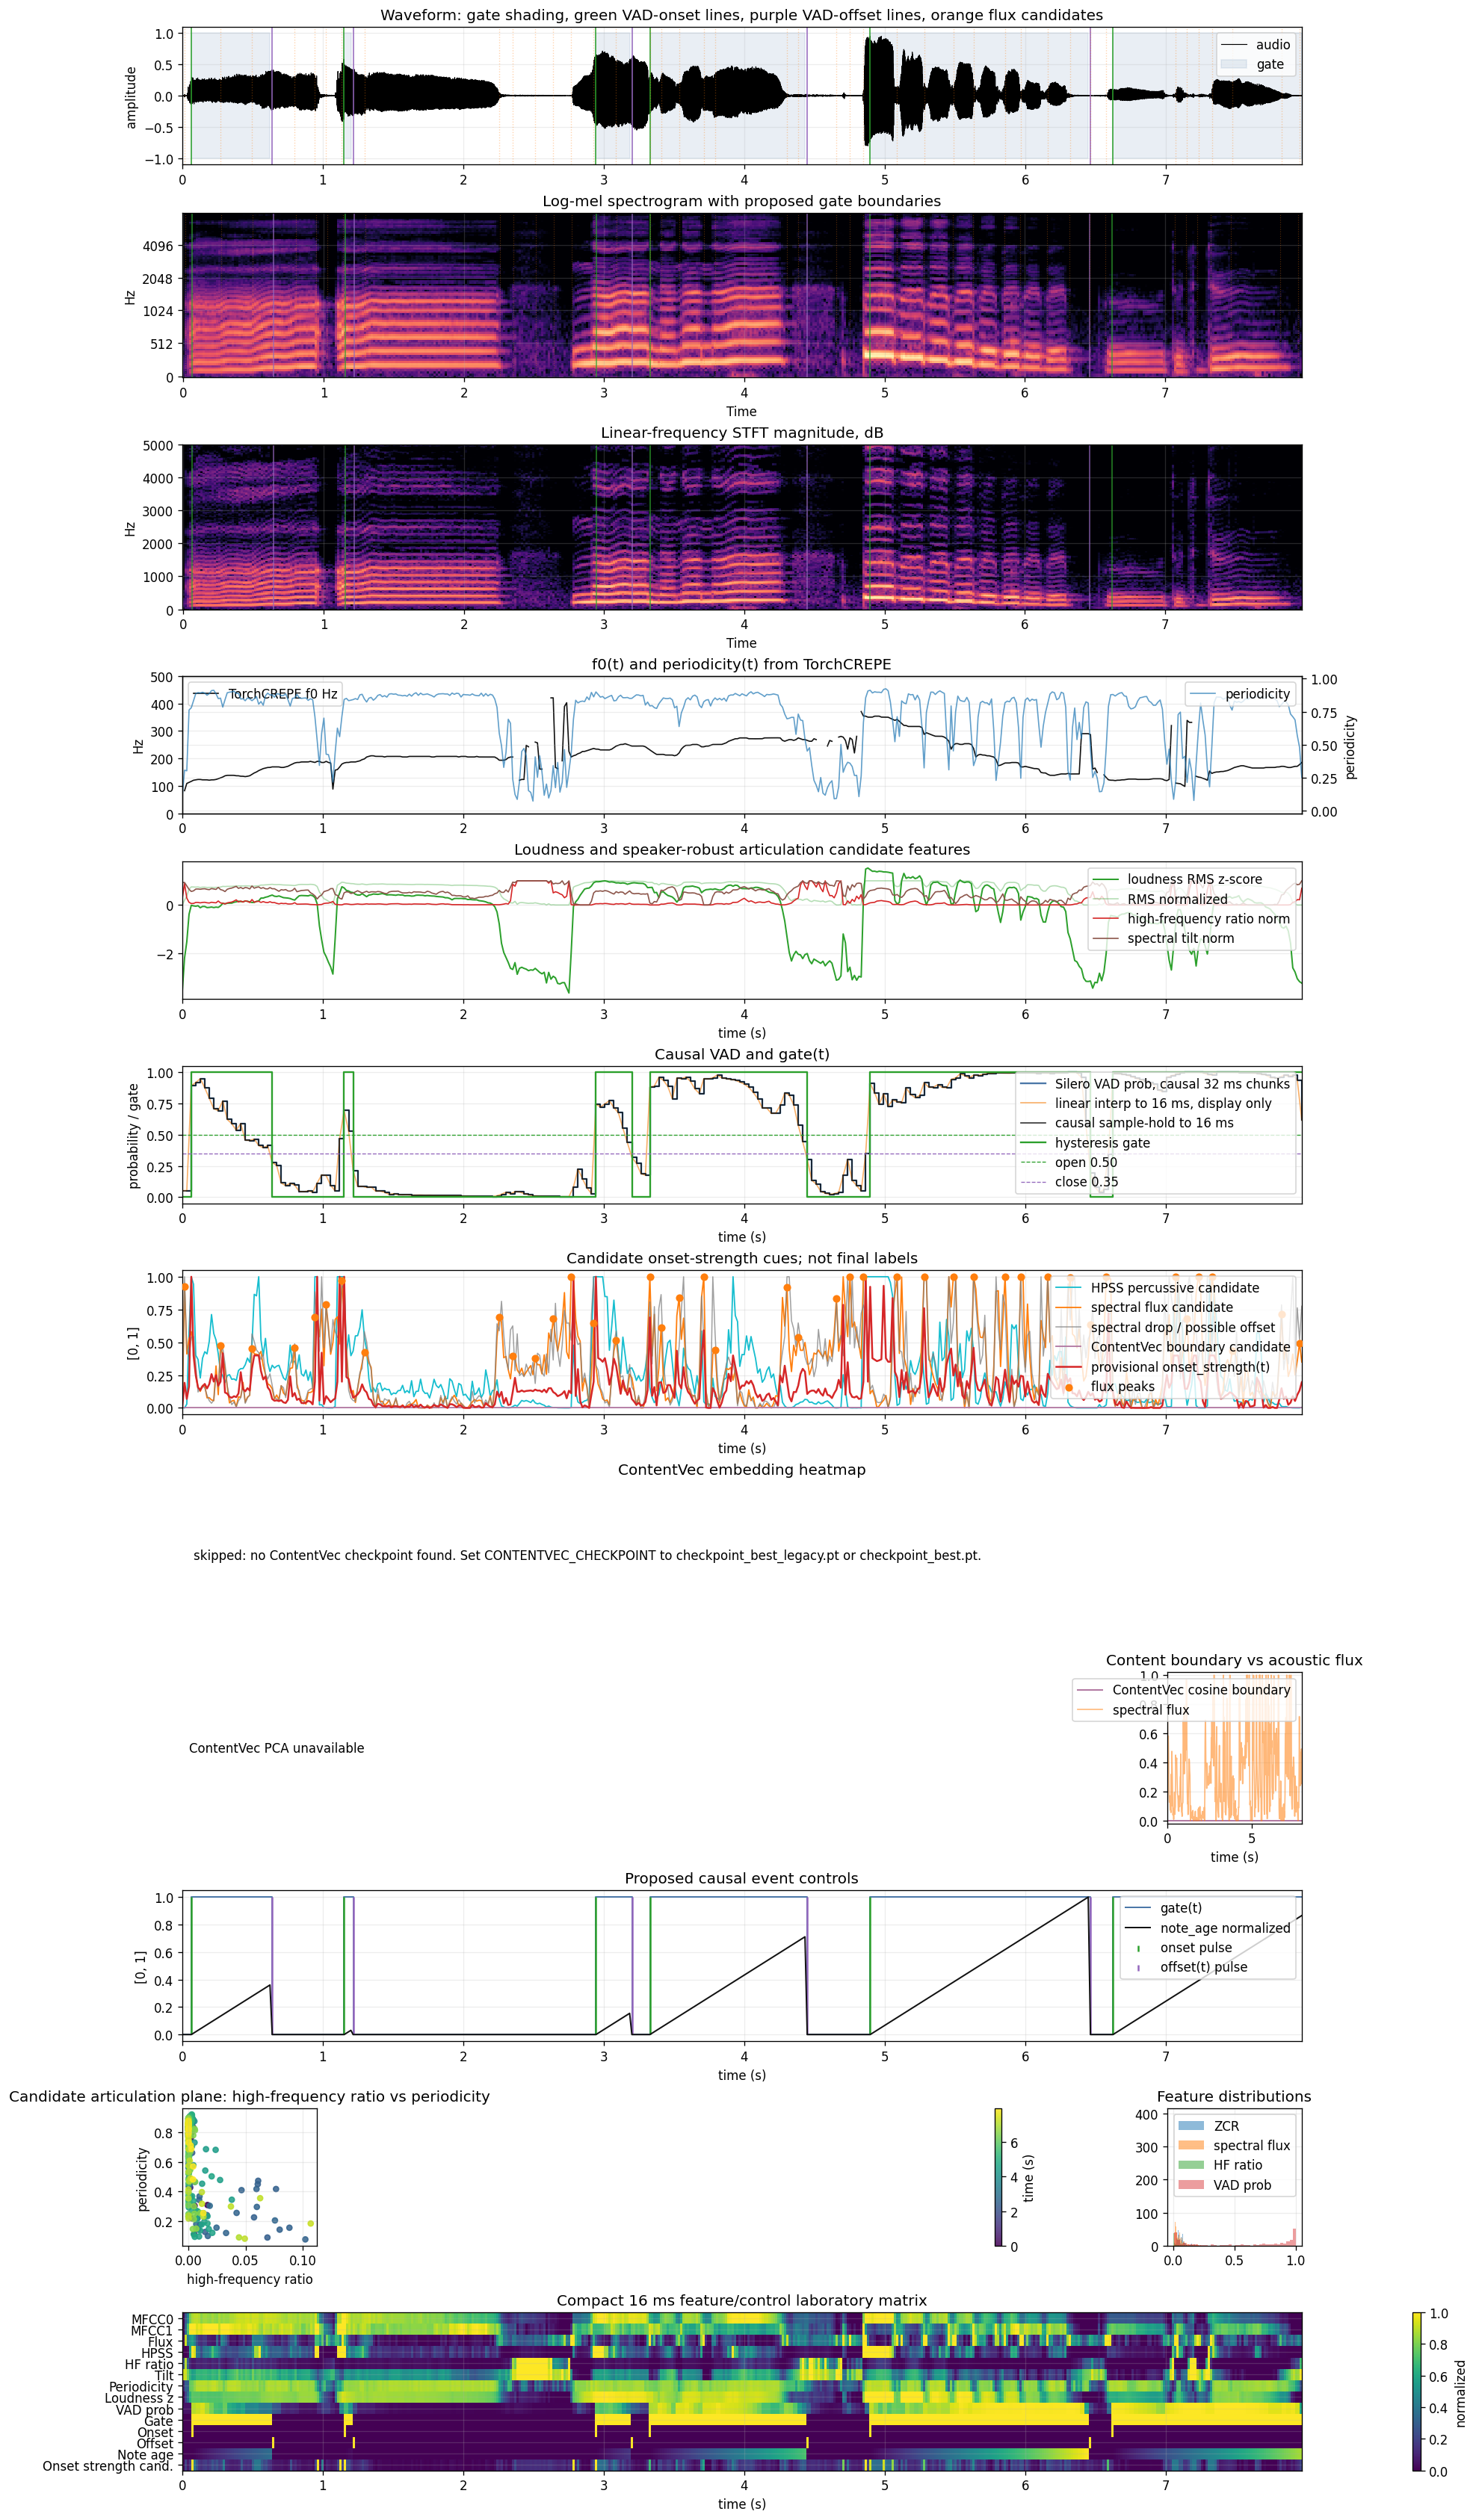

In [18]:
audio_time = np.arange(len(y)) / sr
log_power_db = librosa.power_to_db(power, ref=np.max)
mel_db = librosa.power_to_db(
    librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, win_length=win_length, n_mels=96),
    ref=np.max,
)

onset_times = times[onset > 0.5]
offset_times = times[offset > 0.5]

fig = plt.figure(figsize=(16, 28), constrained_layout=True)
gs = fig.add_gridspec(12, 2, height_ratios=[1.0, 1.2, 1.2, 1.0, 1.0, 1.0, 1.05, 1.2, 1.1, 1.1, 1.0, 1.15])

ax = fig.add_subplot(gs[0, :])
ax.plot(audio_time, y, color='black', linewidth=0.7, label='audio')
ax.fill_between(times, -1.0, 1.0, where=gate > 0.5, color='#4c78a8', alpha=0.12, step='mid', label='gate')
for t in onset_times:
    ax.axvline(t, color='#2ca02c', alpha=0.85, linewidth=1.1)
for t in offset_times:
    ax.axvline(t, color='#9467bd', alpha=0.85, linewidth=1.1)
for t in flux_peak_times:
    ax.axvline(t, color='#ff7f0e', alpha=0.35, linewidth=0.8, linestyle=':')
ax.set_title('Waveform: gate shading, green VAD-onset lines, purple VAD-offset lines, orange flux candidates')
ax.set_ylabel('amplitude')
ax.set_xlim(0, audio_time[-1] if len(audio_time) else 0)
ax.legend(loc='upper right')

ax = fig.add_subplot(gs[1, :])
librosa.display.specshow(mel_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel', cmap='magma', ax=ax)
for t in onset_times:
    ax.axvline(t, color='#2ca02c', alpha=0.85, linewidth=0.9)
for t in offset_times:
    ax.axvline(t, color='#9467bd', alpha=0.85, linewidth=0.9)
for t in flux_peak_times:
    ax.axvline(t, color='#ff7f0e', alpha=0.35, linewidth=0.7, linestyle=':')
ax.set_title('Log-mel spectrogram with proposed gate boundaries')

ax = fig.add_subplot(gs[2, :])
librosa.display.specshow(log_power_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='hz', cmap='magma', ax=ax)
ax.set_ylim(0, min(5000, sr / 2))
for t in onset_times:
    ax.axvline(t, color='#2ca02c', alpha=0.85, linewidth=0.9)
for t in offset_times:
    ax.axvline(t, color='#9467bd', alpha=0.85, linewidth=0.9)
ax.set_title('Linear-frequency STFT magnitude, dB')

ax = fig.add_subplot(gs[3, :])
f0_masked = np.where(periodicity > 0.15, f0_hz, np.nan)
ax.plot(times, f0_masked, color='#111111', linewidth=1.0, label='TorchCREPE f0 Hz')
ax.set_ylabel('Hz')
ax.set_ylim(0, max(500.0, np.nanmax(f0_masked) * 1.15 if np.any(np.isfinite(f0_masked)) else 500.0))
ax2 = ax.twinx()
ax2.plot(times, periodicity, color='#1f77b4', alpha=0.7, linewidth=1.0, label='periodicity')
ax2.set_ylim(-0.02, 1.02)
ax2.set_ylabel('periodicity')
ax.set_title('f0(t) and periodicity(t) from TorchCREPE')
ax.set_xlim(0, times[-1] if len(times) else 0)
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

ax = fig.add_subplot(gs[4, :])
ax.plot(times, loudness_z, color='#2ca02c', linewidth=1.2, label='loudness RMS z-score')
ax.plot(times, energy_norm, color='#2ca02c', alpha=0.35, linewidth=1.0, label='RMS normalized')
ax.plot(times, high_freq_ratio_norm, color='#d62728', linewidth=1.0, label='high-frequency ratio norm')
ax.plot(times, spectral_tilt_norm, color='#8c564b', linewidth=1.0, label='spectral tilt norm')
ax.set_title('Loudness and speaker-robust articulation candidate features')
ax.set_xlabel('time (s)')
ax.set_xlim(0, times[-1] if len(times) else 0)
ax.legend(loc='upper right')

ax = fig.add_subplot(gs[5, :])
ax.step(causal_vad_times, causal_vad_probs, where='post', color='#4c78a8', linewidth=1.4, label='Silero VAD prob, causal 32 ms chunks')
ax.plot(times, vad_prob_interp_16ms, color='#f58518', linewidth=1.0, alpha=0.65, label='linear interp to 16 ms, display only')
ax.step(times, vad_prob_16ms, where='post', color='#000000', linewidth=1.0, alpha=0.8, label='causal sample-hold to 16 ms')
ax.step(times, gate, where='post', color='#2ca02c', linewidth=1.4, label='hysteresis gate')
ax.axhline(VAD_OPEN_THRESHOLD, color='#2ca02c', linestyle='--', linewidth=0.8, label=f'open {VAD_OPEN_THRESHOLD:.2f}')
ax.axhline(VAD_CLOSE_THRESHOLD, color='#9467bd', linestyle='--', linewidth=0.8, label=f'close {VAD_CLOSE_THRESHOLD:.2f}')
ax.set_title('Causal VAD and gate(t)')
ax.set_xlabel('time (s)')
ax.set_ylabel('probability / gate')
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(0, times[-1] if len(times) else 0)
ax.legend(loc='upper right')

ax = fig.add_subplot(gs[6, :])
ax.plot(times, hpss_onset_norm, color='#17becf', linewidth=1.1, label='HPSS percussive candidate')
ax.plot(times, flux_norm, color='#ff7f0e', linewidth=1.1, label='spectral flux candidate')
ax.plot(times, drop_norm, color='#7f7f7f', linewidth=0.9, alpha=0.75, label='spectral drop / possible offset')
ax.plot(times, contentvec_boundary_16ms, color='#b279a2', linewidth=1.1, label='ContentVec boundary candidate')
ax.plot(times, onset_strength_candidate, color='#d62728', linewidth=1.5, label='provisional onset_strength(t)')
ax.scatter(flux_peak_times, flux_norm[flux_peak_frames], color='#ff7f0e', s=26, zorder=3, label='flux peaks')
ax.set_title('Candidate onset-strength cues; not final labels')
ax.set_xlabel('time (s)')
ax.set_ylabel('[0, 1]')
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(0, times[-1] if len(times) else 0)
ax.legend(loc='upper right')

ax = fig.add_subplot(gs[7, :])
if contentvec_features is not None:
    n_show = min(48, contentvec_features.shape[1])
    cv_show = contentvec_features[:, :n_show].T
    im = ax.imshow(
        cv_show,
        aspect='auto',
        interpolation='nearest',
        cmap='viridis',
        extent=[contentvec_times[0], contentvec_times[-1] if len(contentvec_times) else 0, n_show, 0],
    )
    ax.set_title(f'ContentVec embedding heatmap, first {n_show} channels')
    ax.set_ylabel('channel')
    ax.set_xlabel('time (s)')
    fig.colorbar(im, ax=ax, label='activation')
else:
    ax.text(0.01, 0.55, contentvec_status, transform=ax.transAxes, va='center', wrap=True)
    ax.set_title('ContentVec embedding heatmap')
    ax.set_axis_off()

ax = fig.add_subplot(gs[8, 0])
if contentvec_features is not None and len(contentvec_pca):
    sc = ax.scatter(contentvec_pca[:, 0], contentvec_pca[:, 1], c=contentvec_times, cmap='plasma', s=16, alpha=0.85)
    ax.set_title('ContentVec PCA trajectory')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    fig.colorbar(sc, ax=ax, label='time (s)')
else:
    ax.text(0.05, 0.5, 'ContentVec PCA unavailable', transform=ax.transAxes, va='center')
    ax.set_axis_off()

ax = fig.add_subplot(gs[8, 1])
ax.plot(times, contentvec_boundary_16ms, color='#b279a2', linewidth=1.2, label='ContentVec cosine boundary')
ax.plot(times, flux_norm, color='#ff7f0e', alpha=0.55, linewidth=1.0, label='spectral flux')
ax.set_xlim(0, times[-1] if len(times) else 0)
ax.set_ylim(-0.02, 1.02)
ax.legend(loc='upper right')
ax.set_title('Content boundary vs acoustic flux')
ax.set_xlabel('time (s)')

ax = fig.add_subplot(gs[9, :])
ax.step(times, gate, where='post', color='#4c78a8', linewidth=1.2, label='gate(t)')
ax.stem(times, onset, linefmt='#2ca02c', markerfmt=' ', basefmt=' ', label='onset pulse')
ax.stem(times, offset, linefmt='#9467bd', markerfmt=' ', basefmt=' ', label='offset(t) pulse')
ax.plot(times, np.clip(note_age / max(np.max(note_age), 1e-6), 0.0, 1.0), color='#111111', linewidth=1.2, label='note_age normalized')
ax.set_title('Proposed causal event controls')
ax.set_xlabel('time (s)')
ax.set_ylabel('[0, 1]')
ax.set_xlim(0, times[-1] if len(times) else 0)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='upper right')

ax = fig.add_subplot(gs[10, 0])
sc = ax.scatter(high_freq_ratio, periodicity, c=times[:len(high_freq_ratio)], cmap='viridis', s=18, alpha=0.85)
ax.set_title('Candidate articulation plane: high-frequency ratio vs periodicity')
ax.set_xlabel('high-frequency ratio')
ax.set_ylabel('periodicity')
fig.colorbar(sc, ax=ax, label='time (s)')

ax = fig.add_subplot(gs[10, 1])
ax.hist(zcr, bins=40, alpha=0.50, label='ZCR')
ax.hist(spectral_flux, bins=40, alpha=0.50, label='spectral flux')
ax.hist(high_freq_ratio, bins=40, alpha=0.50, label='HF ratio')
if causal_vad_probs.size:
    ax.hist(causal_vad_probs, bins=40, alpha=0.45, label='VAD prob')
ax.set_title('Feature distributions')
ax.legend()

ax = fig.add_subplot(gs[11, :])
compact_rows = [
    robust_normalize(mfcc[0]),
    robust_normalize(mfcc[1]),
    flux_norm,
    hpss_onset_norm,
    high_freq_ratio_norm,
    spectral_tilt_norm,
    periodicity,
    robust_normalize(loudness_z),
    vad_prob_16ms,
    gate,
    onset,
    offset,
    np.clip(note_age / max(np.max(note_age), 1e-6), 0.0, 1.0),
    onset_strength_candidate,
]
compact_labels = [
    'MFCC0',
    'MFCC1',
    'Flux',
    'HPSS',
    'HF ratio',
    'Tilt',
    'Periodicity',
    'Loudness z',
    'VAD prob',
    'Gate',
    'Onset',
    'Offset',
    'Note age',
    'Onset strength cand.',
]
if contentvec_features is not None:
    compact_rows.append(contentvec_boundary_16ms)
    compact_labels.append('ContentVec boundary')
compact = np.vstack(compact_rows)
im = ax.imshow(compact, aspect='auto', interpolation='nearest', cmap='viridis', extent=[times[0], times[-1], compact.shape[0], 0])
ax.set_yticks(np.arange(0.5, len(compact_labels) + 0.5))
ax.set_yticklabels(compact_labels)
ax.set_xlabel('time (s)')
ax.set_title('Compact 16 ms feature/control laboratory matrix')
fig.colorbar(im, ax=ax, label='normalized')

plt.show()


## 6. Export 16 ms Features And Proposed Controls

`feature_tensor` contains acoustic analysis features. `feature_tensor_plus` appends the current proposed Bass-DDSP front-end controls and optional ContentVec diagnostics aligned to the same 16 ms grid.


In [19]:
control_tensor = np.stack([
    f0_hz,
    loudness_z,
    gate,
    onset_strength_candidate,
    offset,
    note_age,
    periodicity,
    vad_prob_16ms,
    vad_prob_interp_16ms,
    hpss_onset_norm,
    flux_norm,
    high_freq_ratio,
    spectral_tilt,
], axis=1).astype(np.float32)

control_names = [
    'f0_hz_torchcrepe',
    'loudness_rms_z',
    'gate_causal_vad',
    'onset_strength_candidate',
    'offset_causal_vad',
    'note_age_seconds',
    'periodicity_torchcrepe',
    'causal_vad_prob_sample_hold',
    'causal_vad_prob_interp_display',
    'hpss_onset_candidate',
    'spectral_flux_candidate',
    'high_freq_ratio',
    'spectral_tilt_db',
]

optional_blocks = []
optional_names = []
if contentvec_features is not None:
    optional_blocks.append(contentvec_pca_16ms.astype(np.float32))
    optional_names.extend(['contentvec_pca_0', 'contentvec_pca_1'])
    optional_blocks.append(contentvec_boundary_16ms[:, None].astype(np.float32))
    optional_names.append('contentvec_boundary_norm')
    optional_blocks.append(contentvec_novelty_16ms[:, None].astype(np.float32))
    optional_names.append('contentvec_novelty_norm')

feature_tensor_plus = np.concatenate([feature_tensor, control_tensor] + optional_blocks, axis=1).astype(np.float32)
feature_names_plus = feature_names + control_names + optional_names

df = pd.DataFrame(feature_tensor_plus, columns=feature_names_plus)
df.insert(0, 'time_seconds', times[:len(df)])
df['flux_norm'] = flux_norm[:len(df)]
df['zcr_norm'] = zcr_norm[:len(df)]
df['energy_norm'] = energy_norm[:len(df)]
df['is_flux_peak'] = False
df.loc[flux_peak_frames[flux_peak_frames < len(df)], 'is_flux_peak'] = True
df['is_gate_onset'] = onset.astype(bool)
df['is_gate_offset'] = offset.astype(bool)

contentvec_features_np = (
    np.asarray(contentvec_features, dtype=np.float32)
    if contentvec_features is not None
    else np.zeros((0, 0), dtype=np.float32)
)
contentvec_times_np = (
    np.asarray(contentvec_times, dtype=np.float32)
    if contentvec_times is not None
    else np.zeros(0, dtype=np.float32)
)

out_npz = 'scat_features_16ms.npz'
out_csv = 'scat_features_16ms.csv'
np.savez(
    out_npz,
    y=y,
    sr=sr,
    times=times,
    hop_seconds=np.array(HOP_SECONDS, dtype=np.float32),
    feature_tensor=feature_tensor,
    feature_names=np.array(feature_names),
    control_tensor=control_tensor,
    control_names=np.array(control_names),
    feature_tensor_plus=feature_tensor_plus,
    feature_names_plus=np.array(feature_names_plus),
    mfcc=mfcc,
    mfcc_delta=mfcc_delta,
    zcr=zcr,
    spectral_flux=spectral_flux,
    spectral_drop=spectral_drop,
    hpss_percussive=hpss_percussive,
    high_freq_ratio=high_freq_ratio,
    spectral_tilt=spectral_tilt,
    flux_peak_frames=flux_peak_frames,
    hpss_peak_frames=hpss_peak_frames,
    f0_hz=f0_hz,
    loudness_z=loudness_z,
    gate=gate,
    onset=onset,
    offset=offset,
    note_age=note_age,
    periodicity=periodicity,
    onset_strength_candidate=onset_strength_candidate,
    causal_vad_times=causal_vad_times,
    causal_vad_probs=causal_vad_probs,
    vad_prob_16ms=vad_prob_16ms,
    vad_prob_interp_16ms=vad_prob_interp_16ms,
    contentvec_features=contentvec_features_np,
    contentvec_times=contentvec_times_np,
    contentvec_pca=contentvec_pca,
    contentvec_pca_16ms=contentvec_pca_16ms,
    contentvec_boundary=contentvec_boundary,
    contentvec_boundary_16ms=contentvec_boundary_16ms,
    contentvec_novelty=contentvec_novelty,
    contentvec_novelty_16ms=contentvec_novelty_16ms,
    contentvec_status=np.array(contentvec_status),
    causal_vad_status=np.array(causal_vad_status),
    torchcrepe_status=np.array(torchcrepe_status),
)
df.to_csv(out_csv, index=False)

print('Saved:', out_npz)
print('Saved:', out_csv)
print('Base feature input shape after batching:', (1, *feature_tensor.shape))
print('Control tensor shape after batching:', (1, *control_tensor.shape))
print('Plus tensor shape after batching:', (1, *feature_tensor_plus.shape))
print('Control names:', control_names)
print('Optional added features:', optional_names)
display(df.head(12))


Saved: scat_features_16ms.npz
Saved: scat_features_16ms.csv
Base feature input shape after batching: (1, 499, 47)
Control tensor shape after batching: (1, 499, 13)
Plus tensor shape after batching: (1, 499, 60)
Control names: ['f0_hz_torchcrepe', 'loudness_rms_z', 'gate_causal_vad', 'onset_strength_candidate', 'offset_causal_vad', 'note_age_seconds', 'periodicity_torchcrepe', 'causal_vad_prob_sample_hold', 'causal_vad_prob_interp_display', 'hpss_onset_candidate', 'spectral_flux_candidate', 'high_freq_ratio', 'spectral_tilt_db']
Optional added features: []


,time_seconds,mfcc_00,mfcc_01,mfcc_02,mfcc_03,mfcc_04,mfcc_05,mfcc_06,mfcc_07,mfcc_08,...,hpss_onset_candidate,spectral_flux_candidate,high_freq_ratio,spectral_tilt_db,flux_norm,zcr_norm,energy_norm,is_flux_peak,is_gate_onset,is_gate_offset
0,0.000,-604.708557,33.451416,28.447258,21.519484,14.141941,7.521427,2.384951,-0.972873,-2.579416,...,0.000000,0.000000,0.004993,-17.575214,0.000000,0.000000,0.000000,False,False,False
1,0.016,-501.276733,97.330162,-3.723768,-30.989519,-19.137165,11.428898,-1.928573,-5.593288,3.600380,...,0.000000,0.923637,0.016693,-17.436295,0.923637,0.490368,0.199333,True,False,False
2,0.032,-441.820374,140.361816,-2.942028,-24.396355,-8.824632,13.184196,-8.709795,-11.269998,0.184789,...,0.029054,0.411237,0.005396,-21.773106,0.411237,0.718039,0.368101,False,False,False
3,0.048,-351.922272,173.265518,-12.182398,-22.927410,-31.143682,6.138523,-9.453346,-13.743148,-4.744634,...,0.578960,0.528787,0.002093,-26.185684,0.528787,0.490368,0.654678,False,False,False
4,0.064,-330.081146,185.776398,-20.761847,-29.609871,-29.601871,7.460915,-11.811963,-8.512440,-1.279858,...,1.000000,0.581834,0.001149,-28.887016,0.581834,0.367776,0.748048,False,True,False
5,0.080,-323.910339,185.022430,-20.424280,-27.435783,-33.149223,13.016180,-13.927200,-15.055016,4.090052,...,0.942002,0.455991,0.001244,-28.098251,0.455991,0.350263,0.742182,False,False,False
6,0.096,-322.379059,166.064758,-14.706158,-21.058384,-32.403885,23.749079,-11.119482,-12.977527,-4.306799,...,0.400552,0.248536,0.001989,-25.836746,0.248536,0.367776,0.738648,False,False,False
7,0.112,-328.461761,169.901886,-9.611553,-24.339010,-34.231026,26.391682,-12.902338,-12.271404,-1.232289,...,0.369367,0.155582,0.001989,-25.747519,0.155582,0.437828,0.743783,False,False,False
8,0.128,-344.159973,166.388870,-15.936972,-19.778744,-28.859146,22.575130,-14.653128,-14.396187,-5.029529,...,0.228021,0.126151,0.001673,-26.112621,0.126151,0.437828,0.723024,False,False,False
9,0.144,-334.335449,171.526993,-13.131603,-17.522066,-36.684006,20.020119,-14.000980,-18.452959,-0.818226,...,0.378963,0.171480,0.002021,-25.587700,0.171480,0.525394,0.736034,False,False,False


## Notes For The Scat Analyzer

- The old red/cyan vertical bars were spectral-flux candidate peaks. They were not confirmed onset/offset labels.
- The current notebook uses 16 ms frames to match Bass-DDSP control frames.
- `gate(t)` and `offset(t)` come from causal VAD with hysteresis.
- `note_age(t)` is causal and resets on the current onset pulse.
- `loudness(t)` is RMS z-score, and should not be used as onset strength by itself.
- `onset_strength(t)` is still unresolved. Inspect HPSS, spectral flux, high-frequency ratio, VAD rise, and ContentVec boundary cues separately.
- Spectral flux can fire at offsets; do not treat it as an onset detector without boundary logic.
- `articulation_id(t)` should be note-latched: classify during the first 80-160 ms after onset, then hold that class until offset.
- The planned articulation classifier is causal: spectral tilt / high-frequency ratio / periodicity / ZCR / optional ContentVec -> GRU -> softmax.
